In [3]:
import os
from math import radians
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import Dataset
#xr.set_options(use_new_combine_kwarg_defaults=True) # Avoid xarray warnings


datasets = {
    "GFDL": {
        "evap":  (r"../../../Data-for-teaching-staff/Droughts/rcp/gfdl_evaporation", "evspsbl", 31557.6),
        "precip":(r"../../../Data-for-teaching-staff/Droughts/rcp/gfdl_precipitation", "pr", 31557.6),
        "soil":  (r"../../../Data-for-teaching-staff/Droughts/rcp/gfdl_soilmoisture", "mrso", 1),
        "start_year": 1860
    },
    "MIROC": {
        "evap":  (r"../../../Data-for-teaching-staff/Droughts/rcp/miroc_e", "evspsbl", 31557.6),
        "precip":(r"../../../Data-for-teaching-staff/Droughts/rcp/miroc_p", "pr", 31557.6),
        "soil":  (r"../../../Data-for-teaching-staff/Droughts/rcp/miroc_m", "mrso", 1),
        "start_year": 1850
    }
}

"""
datasets = {
    "GFDL": {
        "evap":  (r"/Users/joostvanasperen/Documents/Work/rcp/gfdl_evaporation", "evspsbl", 31557.6),
        "precip":(r"/Users/joostvanasperen/Documents/Work/rcp/gfdl_precipitation", "pr", 31557.6),
        "soil":  (r"/Users/joostvanasperen/Documents/Work/rcp/gfdl_soilmoisture", "mrso", 1),
        "start_year": 1860
    },
    "MIROC": {
        "evap":  (r"/Users/joostvanasperen/Documents/Work/rcp/miroc_e", "evspsbl", 31557.6),
        "precip":(r"/Users/joostvanasperen/Documents/Work/rcp/miroc_p", "pr", 31557.6),
        "soil":  (r"/Users/joostvanasperen/Documents/Work/rcp/miroc_m", "mrso", 1),
        "start_year": 1850
    }
}
"""

# Define regions (lat/lon slices). Wrap-around longitude dealt with in function, handled later.
regions = {
    "Sahel": {"lat": slice(10, 20), "lon": slice(345, 40)},
    "SW_US": {"lat": slice(32, 41), "lon": slice(235, 255)}
}

# -------------------------------------------------------------------
# Load the local data
# -------------------------------------------------------------------
def load_variable(path, var_name, factor=1.0):
    """Load and concatenate all NetCDF files in a folder as an xarray.DataArray"""
    nc_files = sorted([os.path.join(path, f) for f in os.listdir(path) if f.endswith(".nc")])
    if not nc_files:
        raise FileNotFoundError(f"No .nc files found in {path}") 
    da = xr.open_mfdataset(nc_files, combine='by_coords',decode_timedelta=False, engine='netcdf4')[var_name]

    return da * factor

data = {}
for model, info in datasets.items():
    data[model] = {}
    for var in ["evap", "precip", "soil"]:
        path, var_name, factor = info[var]
        print(f"Loading {model} {var} from {path}...")
        data[model][var] = load_variable(path, var_name, factor)
    data[model]["start_year"] = info["start_year"]

# -------------------------------------------------------------------
# Compute yearly averages
# -------------------------------------------------------------------

yearly_data = {} 
for model, vars_dict in data.items(): 
    yearly_data[model] = {}
    for var_key in ["evap", "precip", "soil"]:
        da = vars_dict[var_key] 
        # Compute yearly mean (resampling from monthly to yearly) 
        yearly_mean = da.resample(time="YS").mean() 
        # Store in the new dict 
        yearly_data[model][var_key] = yearly_mean 
    yearly_data[model]["start_year"] = vars_dict["start_year"] 

print("Yearly averages computed.")

# -------------------------------------------------------------------
# Subset regions
# -------------------------------------------------------------------

# xarray allows for easy data selection, but this method didn't handle wrap-around longitudes and caused some issues. 
#Longer more robust version below this. 
#def subset_region(da, region): 
# return da.sel(lat=region["lat"], lon=region["lon"])

def subset_region(da, region):
    """
    Slice a DataArray by latitude and longitude, handling longitude wrap-around.
    Returns a regional DataArray.
    """
    da_region = da.sel(lat=region["lat"])
    lon_min, lon_max = region["lon"].start, region["lon"].stop
    lons = da_region["lon"].values

    # Convert negative longitudes to 0-360
    if np.any(lons < 0):
        lons = np.where(lons < 0, lons + 360, lons)
        da_region = da_region.assign_coords(lon=lons)

    # Wrap-around selection
    if lon_min > lon_max:
        da_region = da_region.where((da_region.lon >= lon_min) | (da_region.lon <= lon_max), drop=True)
    else:
        da_region = da_region.sel(lon=slice(lon_min, lon_max))

    return da_region

# Slice by region
regional_data = {}
for model, vars_dict in yearly_data.items():
    regional_data[model] = {}
    for var in ["evap", "precip", "soil"]:
        regional_data[model][var] = {}
        for region_name, bounds in regions.items():
            regional_data[model][var][region_name] = subset_region(vars_dict[var], bounds)

print("Regional slices selected.")

# -------------------------------------------------------------------
# Compute area-weighted regional means
# -------------------------------------------------------------------

def area_weighted_mean(da):
    """
    Compute area-weighted mean over latitude and longitude.
    Latitude weighting by cos(latitude).
    """
    weights = np.cos(np.deg2rad(da["lat"]))
    weights = weights / weights.mean()  # normalize weights
    return da.weighted(weights).mean(dim=("lat", "lon"))

# Compute area-weighted means
regional_means = {}
for model, vars_dict in regional_data.items():
    regional_means[model] = {}
    for var, regions_dict in vars_dict.items():
        regional_means[model][var] = {}
        for region_name, da_region in regions_dict.items():
            regional_means[model][var][region_name] = area_weighted_mean(da_region)

print("Regional means computed.")

# -------------------------------------------------------------------
# Smoothing functions
# -------------------------------------------------------------------

def smooth_two_pass(values):
    """
    Apply a 1-2-1 smoothing filter twice to a 1D array.
    Returns the array trimmed by 2 points at both ends.
    """
    data_smooth = np.copy(values)
    for _ in range(2):
        temp = np.copy(data_smooth)
        for j in range(1, len(values) - 1):
            temp[j] = 0.25*data_smooth[j-1] + 0.5*data_smooth[j] + 0.25*data_smooth[j+1]
        data_smooth = temp
    return data_smooth[2:-2]

def smooth_and_save(da, start_year, save_path):
    """
    Smooth a regional yearly DataArray and save as a NumPy .npy file.
    """
    values = da.values
    years = np.arange(start_year, start_year + len(values))
    smoothed_values = smooth_two_pass(values)
    smoothed_years = years[2:-2]
    smoothed_series = np.array([smoothed_years, smoothed_values])

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    np.save(save_path, smoothed_series)
    print(f"Saved smoothed series to {save_path}")

# -------------------------------------------------------------------
# Save smoothed regional data
# -------------------------------------------------------------------

# Smooth and save all time series
output_dir = "./Output"
os.makedirs(output_dir, exist_ok=True)

for model, vars_dict in regional_means.items():
    start_year = yearly_data[model]["start_year"]
    for var, regions_dict in vars_dict.items():
        for region_name, da_region in regions_dict.items():
            filename = f"{model.lower()}_{var}_{region_name.lower()}.npy"
            save_path = os.path.join(output_dir, filename)
            smooth_and_save(da_region, start_year, save_path)

print("All models and variables have been saved.")


Loading GFDL evap from ../../../Data-for-teaching-staff/Droughts/rcp/gfdl_evaporation...
Loading GFDL precip from ../../../Data-for-teaching-staff/Droughts/rcp/gfdl_precipitation...
Loading GFDL soil from ../../../Data-for-teaching-staff/Droughts/rcp/gfdl_soilmoisture...
Loading MIROC evap from ../../../Data-for-teaching-staff/Droughts/rcp/miroc_e...
Loading MIROC precip from ../../../Data-for-teaching-staff/Droughts/rcp/miroc_p...
Loading MIROC soil from ../../../Data-for-teaching-staff/Droughts/rcp/miroc_m...
Yearly averages computed.
Regional slices selected.
Regional means computed.
Saved smoothed series to ./Output/gfdl_evap_sahel.npy
Saved smoothed series to ./Output/gfdl_evap_sw_us.npy
Saved smoothed series to ./Output/gfdl_precip_sahel.npy
Saved smoothed series to ./Output/gfdl_precip_sw_us.npy
Saved smoothed series to ./Output/gfdl_soil_sahel.npy
Saved smoothed series to ./Output/gfdl_soil_sw_us.npy
Saved smoothed series to ./Output/miroc_evap_sahel.npy
Saved smoothed series t

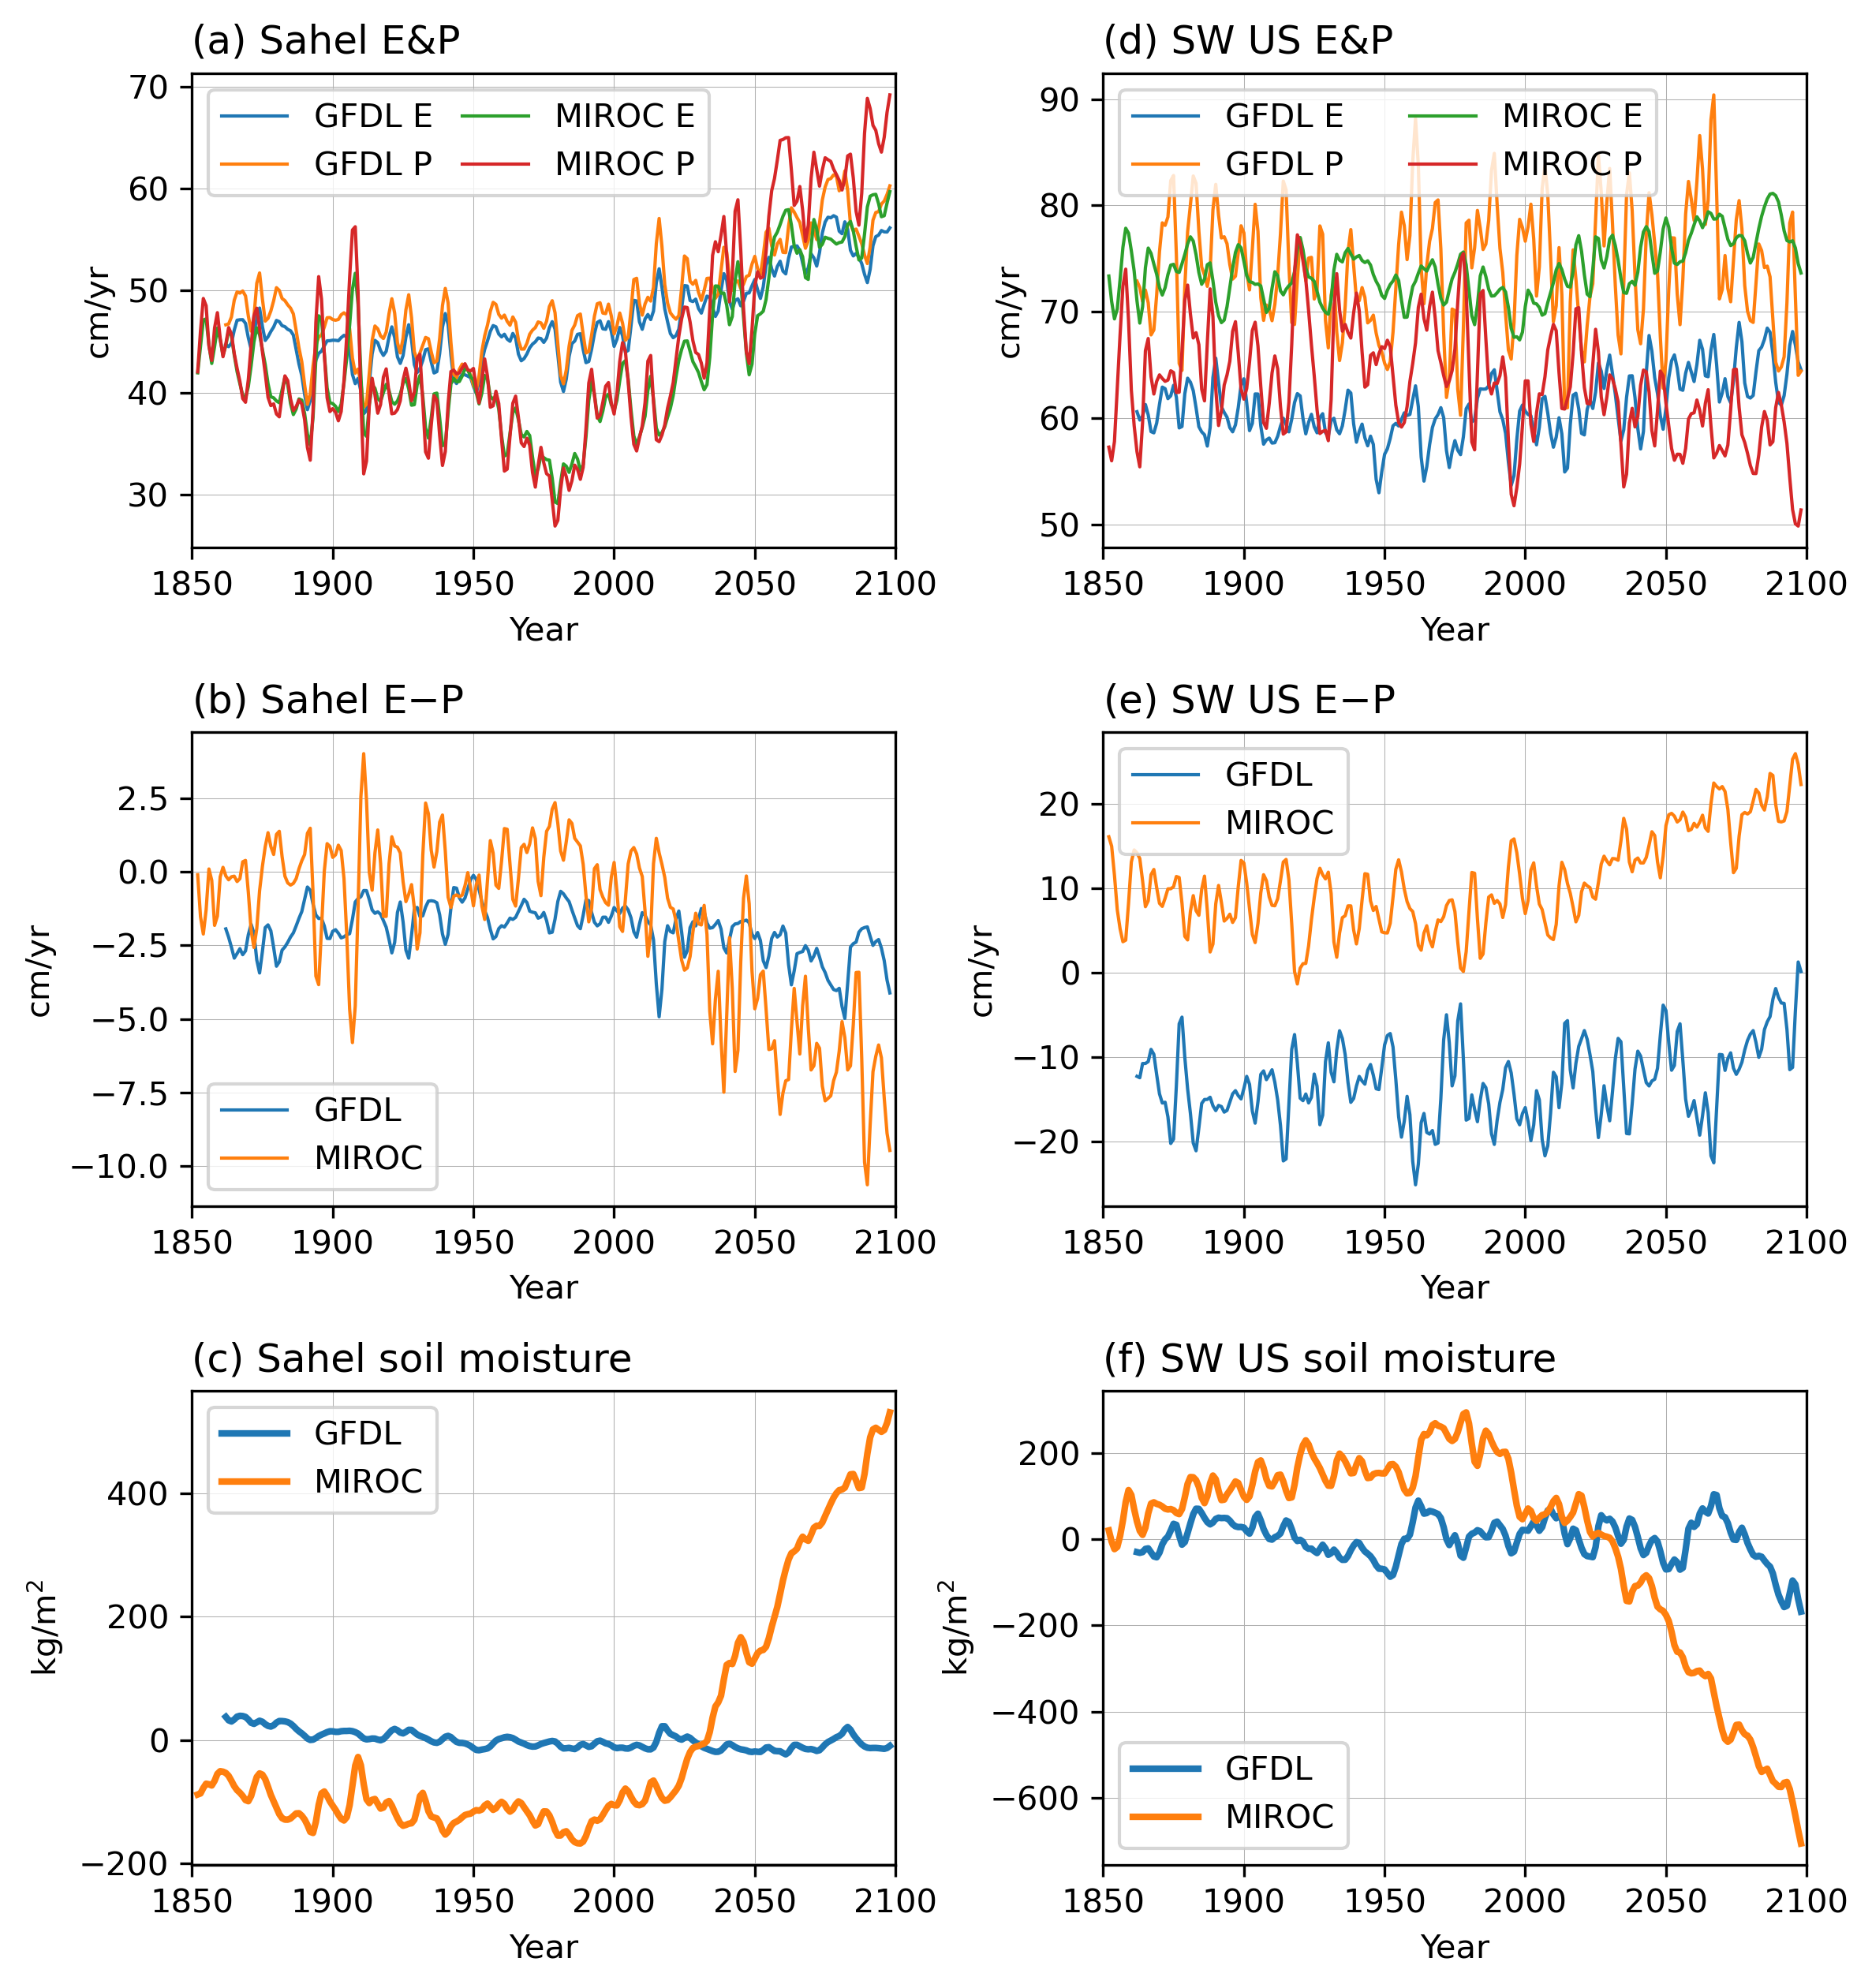

In [4]:
#Nothing changed about the plotting and loading.
#file names are slightly different than original code, so those have been adjusted

###############################################################

sw_miroc_moisture=np.load("./Output/miroc_soil_sw_us.npy") 
sw_miroc_precipitation=np.load("./Output/miroc_precip_sw_us.npy") 
sw_miroc_evaporation=np.load("./Output/miroc_evap_sw_us.npy") 
sw_gfdl_moisture=np.load("./Output/gfdl_soil_sw_us.npy") 
sw_gfdl_precipitation=np.load("./Output/gfdl_precip_sw_us.npy") 
sw_gfdl_evaporation=np.load("./Output/gfdl_evap_sw_us.npy") 
sahel_miroc_moisture=np.load("./Output/miroc_soil_sahel.npy") 
sahel_miroc_precipitation=np.load("./Output/miroc_precip_sahel.npy") 
sahel_miroc_evaporation=np.load("./Output/miroc_evap_sahel.npy") 
sahel_gfdl_moisture=np.load("./Output/gfdl_soil_sahel.npy") 
sahel_gfdl_precipitation=np.load("./Output/gfdl_precip_sahel.npy")
sahel_gfdl_evaporation=np.load("./Output/gfdl_evap_sahel.npy")

fig = plt.figure(1,figsize=(8,8.5), dpi=300); plt.clf()
linewidth=1
plt.subplot(3,2,1)
plt.ylabel("cm/yr")
plt.xlabel("Year")
plt.title("(a) Sahel E&P",loc="left")
plt.plot(sahel_gfdl_evaporation[0,:], sahel_gfdl_evaporation[1,:]*100 \
         , lw=linewidth, label="GFDL E")
plt.plot(sahel_gfdl_precipitation[0,:], sahel_gfdl_precipitation[1,:]*100 \
         , lw=linewidth, label="GFDL P")
plt.plot(sahel_miroc_evaporation[0,:], sahel_miroc_evaporation[1,:]*100 \
         , lw=linewidth, label="MIROC E")
plt.plot(sahel_miroc_precipitation[0,:], sahel_miroc_precipitation[1,:]*100 \
         , lw=linewidth, label="MIROC P")
plt.xlim([1850, 2100])
plt.grid(lw=0.25)
hleg=plt.legend(ncol=2,columnspacing=0.9)

plt.subplot(3,2,3)
plt.ylabel("cm/yr")
plt.xlabel("Year")
plt.title("(b) Sahel E$-$P",loc="left")
plt.plot(sahel_gfdl_evaporation[0,:], sahel_gfdl_evaporation[1,:]*100 \
         -sahel_gfdl_precipitation[1,:]*100, lw=linewidth,label="GFDL")
plt.plot(sahel_miroc_evaporation[0,:], sahel_miroc_evaporation[1,:]*100 \
         -sahel_miroc_precipitation[1,:]*100, lw=linewidth,label="MIROC")
plt.xlim([1850, 2100])
plt.grid(lw=0.25)
plt.legend()


plt.subplot(3,2,5)
plt.ylabel("kg/m$^2$")
plt.xlabel("Year")
plt.title("(c) Sahel soil moisture",loc="left")
mean_gfdl=np.mean(sahel_gfdl_moisture[1,:])
mean_miroc=np.mean(sahel_miroc_moisture[1,:])
plt.plot(sahel_gfdl_moisture[0,:], sahel_gfdl_moisture[1,:]-mean_gfdl \
         , lw=2, label="GFDL")
plt.plot(sahel_miroc_moisture[0,:], sahel_miroc_moisture[1,:]-mean_miroc \
         , lw=2, label="MIROC")
plt.xlim([1850, 2100])
plt.grid(lw=0.25)
plt.legend()


plt.subplot(3,2,2)
plt.ylabel("cm/yr")
plt.xlabel("Year")
plt.title("(d) SW US E&P",loc="left")
plt.plot(sw_gfdl_evaporation[0,:], sw_gfdl_evaporation[1,:]*100 \
         , lw=linewidth, label="GFDL E")
plt.plot(sw_gfdl_precipitation[0,:], sw_gfdl_precipitation[1,:]*100 \
         , lw=linewidth, label="GFDL P")
plt.plot(sw_miroc_evaporation[0,:], sw_miroc_evaporation[1,:]*100 \
         , lw=linewidth, label="MIROC E")
plt.plot(sw_miroc_precipitation[0,:], sw_miroc_precipitation[1,:]*100 \
         , lw=linewidth, label="MIROC P")
plt.xlim([1850, 2100])
plt.grid(lw=0.25)
plt.legend(ncol=2)


plt.subplot(3,2,4)
plt.ylabel("cm/yr")
plt.xlabel("Year")
plt.title("(e) SW US E$-$P",loc="left")
plt.plot(sw_gfdl_evaporation[0,:], sw_gfdl_evaporation[1,:]*100 \
         -sw_gfdl_precipitation[1,:]*100, lw=linewidth,label="GFDL")
plt.plot(sw_miroc_evaporation[0,:], sw_miroc_evaporation[1,:]*100 \
         -sw_miroc_precipitation[1,:]*100, lw=linewidth,label="MIROC")
plt.xlim([1850, 2100])
plt.grid(lw=0.25)
plt.legend()


plt.subplot(3,2,6)
plt.ylabel("kg/m$^2$")
plt.xlabel("Year")
plt.title("(f) SW US soil moisture",loc="left")
mean_gfdl=np.mean(sw_gfdl_moisture[1,:])
mean_miroc=np.mean(sw_miroc_moisture[1,:])
plt.plot(sw_gfdl_moisture[0,:], sw_gfdl_moisture[1,:]-mean_gfdl \
         , lw=2, label="GFDL")
plt.plot(sw_miroc_moisture[0,:], sw_miroc_moisture[1,:]-mean_miroc \
         , lw=2, label="MIROC")
plt.xlim([1850, 2100])
plt.grid(lw=0.25)
plt.legend()


plt.tight_layout(w_pad=0)
plt.show()

## save as pdf:
#fig.savefig("Output/Figure-newnew.pdf",format='pdf');
